# Notebook 01: Análisis de etiquetas de fractura
Este noteboos contiene el análisis exploratorio para el archivo train.csv que contiene flags para fractura en cada una de las vertebras, por paciente.

Se busca determinar en que vertebras es más común el que se de una fractura, para poder tomarlo en cuenta en la metodología al momento de diseñar el entrenamiento del modelo ya que se debe tomar en cuenta el desbalance de clases. Además se busca determinar que no haya pacientes 'nulos', es decir, que se cuente con información sobre la fractura más no se tenga la imagen ya que estos casos no servirían para el proyecto. 

*Nota: Este notebook debe correrse en el editor de kaggle para poder acceder a los datos sin tener la necesidad de descargarlos.*

## 0. Configuración

### Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Parámetros 

In [ ]:
# Configuración visual
sns.set_theme(style="whitegrid")

# Rutas
base_dir = "/kaggle/input/competitions/rsna-2022-cervical-spine-fracture-detection"
path_train = os.path.join(base_dir, "train.csv")
image_dir = os.path.join(base_dir, "train_images")

# Carga de datos
df_train = pd.read_csv(path_train)
c_columns = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']

## 1. EDA (csv con flags de fractura)

In [2]:
print("--- 1. INFORMACIÓN GENERAL ---")
print(f"Observaciones: {df_train.shape[0]}, Variables: {df_train.shape[1]}")
print(f"Duplicados: {df_train.duplicated().sum()}")

print("\n--- 2. TIPOS Y NULOS ---")
info_df = pd.DataFrame({
    'Tipo': df_train.dtypes,
    'Nulos': df_train.isnull().sum()
})
display(info_df)

print("\n--- 3. VERIFICACIÓN DE INTEGRIDAD (UIDs vs Carpetas) ---")
if os.path.exists(image_dir):
    # Set comprehension para buscar super rápido
    carpetas_imagenes = set(os.listdir(image_dir))
    uids_csv = set(df_train['StudyInstanceUID'])
    
    missing_folders = uids_csv - carpetas_imagenes
    print(f"UIDs en train.csv sin carpeta de imágenes: {len(missing_folders)}")
    
    if missing_folders:
        print(f"Ejemplos faltantes: {list(missing_folders)[:5]}")
else:
    print(f"Directorio de imágenes no detectado en la ruta especificada. Verifica la ruta.")

--- 1. INFORMACIÓN GENERAL ---
Observaciones: 2019, Variables: 9
Duplicados: 0

--- 2. TIPOS Y NULOS ---


,Tipo,Nulos
StudyInstanceUID,object,0
patient_overall,int64,0
C1,int64,0
C2,int64,0
C3,int64,0
C4,int64,0
C5,int64,0
C6,int64,0
C7,int64,0



--- 3. VERIFICACIÓN DE INTEGRIDAD (UIDs vs Carpetas) ---
UIDs en train.csv sin carpeta de imágenes: 0


En total se tienen 2019 observaciones correspondientes al estudio de fracturas en vertebras. El dataset contiene 9 variables, de las cuales las primera es un identificador del scan del paciente, patient overall es una variable binaria para determinar si hay o no una fractura y el resto son variables binarias correspondientes, a cada vertebra, que identifican en donde está dicha fractura si hay.

No hay valores nulos o faltantes para ninguna de las columnas por lo que no es necesario un tratamiento para dichos valores. Además para cada una de las observaciones del training set se cuenta con una carpeta de imagenes correspondiente a su columna cervical. Se pueden utilizar todas las observaciones, al menos en el caso de identificación de fracturas.

In [3]:
# Calculamos el OR lógico buscando el valor máximo de C1 a C7 por fila
df_train['calculated_overall'] = df_train[c_columns].max(axis=1)

# Filtramos donde lo reportado difiera de nuestro cálculo
inconsistencias = df_train[df_train['patient_overall'] != df_train['calculated_overall']]

print(f"Total de inconsistencias encontradas: {len(inconsistencias)}")
if len(inconsistencias) > 0:
    display(inconsistencias[['StudyInstanceUID', 'patient_overall', 'calculated_overall'] + c_columns].head())

Total de inconsistencias encontradas: 0


No existen incosistencias, es decir no hay observaciones en las cuales el paciente esté marcado como con fractura y luego en las variables de vertebras no haya alguna flag de fractura y visceversa, dentro del training set para identificar fracturas por lo que no es necesario un tratamiento de unificación o algo parecido en esta línea.

--- TABLA DE FRECUENCIAS ---


,Frecuencia Absoluta,Proporción (%)
patient_overall,961,47.60
C7,393,19.47
C2,285,14.12
C6,277,13.72
C5,162,8.02
C1,146,7.23
C4,108,5.35
C3,73,3.62


/tmp/ipykernel_58/629906162.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_table.index, y=freq_table['Frecuencia Absoluta'], palette='rocket')


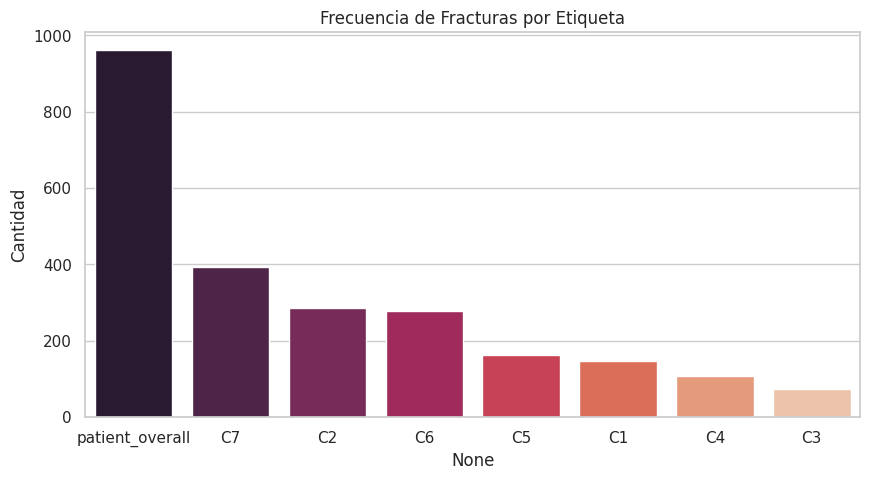

In [11]:
df_fractured=df_train[df_train['patient_overall']==1]
labels = ['patient_overall'] + c_columns

freq_table = pd.DataFrame({
    'Frecuencia Absoluta': df_train[labels].sum(),
    'Proporción (%)': (df_train[labels].mean() * 100).round(2)
}).sort_values(by='Frecuencia Absoluta', ascending=False)

print("--- TABLA DE FRECUENCIAS ---")
display(freq_table)

plt.figure(figsize=(10, 5))
sns.barplot(x=freq_table.index, y=freq_table['Frecuencia Absoluta'], palette='rocket')
plt.title('Frecuencia de Fracturas por Etiqueta')
plt.ylabel('Cantidad')
plt.show()

De los 2019 scans 961 (el 47.60%) posee una fractura en alguna de las vertebras y a partir de esto es válido decir que no existe un desbalance de clases entre fractura y no fractura. 

Ahora en lo que se refiere a fractura en específico sobre alguna vertebra, la mayoría se dan en la C7 (393), estas fracturas representan el 19.47% sobre todo el dataset y el 40.89% sobre las fracturas de espinas cervicales, es decir 2 de cada 5 fracturas se dan el vertebra C7. Para completar el top 3 de vertebras con mas fracturas se debe mencionar que en la vertebra C2 se tienen 285 fracturas (lo cual representa el 14.12% de todo el dataset) y es el 29.66% de fracturas de espinas cervicales, para la vertebra C6 se tienen 277 fracturas (lo cual representa el 13.72% de todo el dataset) y es el 28.82% de todas las fracturas de espinas cervicales.

Este desbalance se debe tomar en cuenta al momento del entrenamiento del modelo si se desea determinar en que vertebra existe una fractura, esto con el fin de evitar que el modelo realiza todas sus predicciones sobre la clase dominante (C7). 

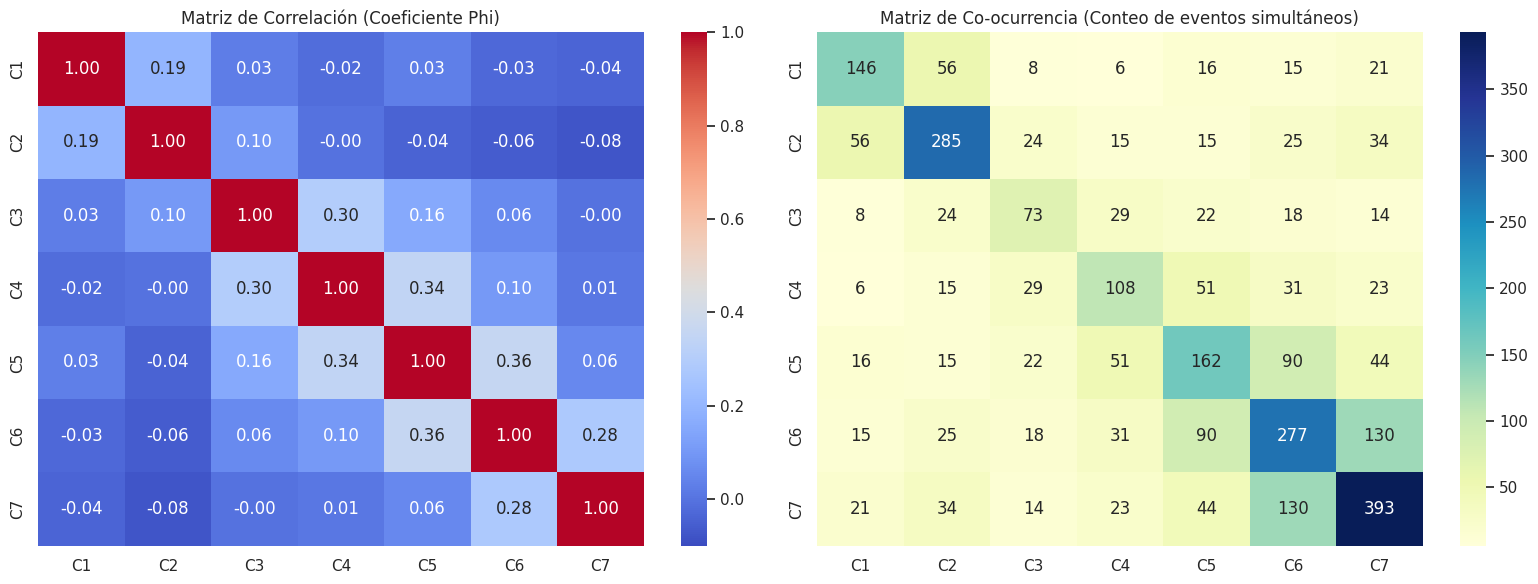

In [5]:
plt.figure(figsize=(16, 6))

# 1. Matriz de Correlación (Phi / Pearson)
plt.subplot(1, 2, 1)
corr_matrix = df_train[c_columns].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-0.1, vmax=1)
plt.title('Matriz de Correlación (Coeficiente Phi)')

# 2. Matriz de Co-ocurrencia
plt.subplot(1, 2, 2)
co_occurrence = df_train[c_columns].T.dot(df_train[c_columns])
sns.heatmap(co_occurrence, annot=True, cmap='YlGnBu', fmt="d")
plt.title('Matriz de Co-ocurrencia (Conteo de eventos simultáneos)')

plt.tight_layout()
plt.show()

Se utiliza el coeficiente phi para medir la correlación entre variables ya que todas son binarias. Es posible observar que no existe una correlación fuerte (entiéndase mayor a 0.85), pero los mayores coeficientes se obtienen entre vertebras adyacentes. Esto hace sentido ya que si una de las vertebras se fractura es por el sometimiento a estres sobre ella y esta fuerza se puede disipar a aquellas vertebras adyacentes causando también una fractura. 

Por otro lado, la matriz de co-ocurrencia refleja la misma información que la matriz de correlación, ya que las fracturas que ocurren al mismo tiempo se dan en su mayoría en vertebras adyacentes. 

In [6]:
# Filtramos solo pacientes con fracturas para no llenar el top con "Sin fractura"
pacientes_con_fractura = df_train[df_train['patient_overall'] == 1].copy()

def obtener_combinacion(row):
    comb = [col for col in c_columns if row[col] == 1]
    return " + ".join(comb)

pacientes_con_fractura['combinacion'] = pacientes_con_fractura.apply(obtener_combinacion, axis=1)
top_15 = pacientes_con_fractura['combinacion'].value_counts().head(15)

print("--- TOP 15 COMBINACIONES DE NIVELES FRACTURADOS ---")
display(pd.DataFrame({'Conteo': top_15}))

--- TOP 15 COMBINACIONES DE NIVELES FRACTURADOS ---


,Conteo
combinacion,
C7,223
C2,180
C6,82
C6 + C7,77
C1,64
C1 + C2,42
C5 + C6,36
C4,28
C5,28


El top 15 conteo de casos, concuerda con lo mostrado anteriormente. Las fracturas en la vertebra C7 es lo más común, aunque vale la pena mencionar que más del 40% de fracturas que se dan dicha vertebra se dan en conjunto con otra fractura en otra vertebra. Con la vertebra C2 sucede algo parecido en el que aproximadamente un 30% de las fracturas en dicha vertebra se dan en conjunto con otra, y en la vertebra C6 aproximadamente el 50% de fracturas se dan en conjunto. 

De la misma manera las fracturas en estas tres vertebras representan más del 50% de fracturas del dataset por lo que se debe tomar en cuenta este desbalance al momento de entrenar al modelo.

In [8]:
# Total de fracturas individuales contando todas las vértebras
total_fracturas_individuales = df_train[c_columns].sum().sum()

# Suma específica de C2, C6 y C7
suma_c2_c6_c7 = df_train[['C2', 'C6', 'C7']].sum().sum()

# Cálculo del porcentaje
porcentaje = (suma_c2_c6_c7 / total_fracturas_individuales) * 100

# Vértebra más frecuente
nivel_mas_frecuente = df_train[c_columns].sum().idxmax()

print("--- VALIDACIÓN CONTRA LITERATURA MÉDICA ---")
print(f"Total de fracturas reportadas: {total_fracturas_individuales}")
print(f"Fracturas concentradas en C2, C6 y C7: {suma_c2_c6_c7}")
print(f"Porcentaje que representan: {porcentaje:.2f}%\n")

--- VALIDACIÓN CONTRA LITERATURA MÉDICA ---
Total de fracturas reportadas: 1444
Fracturas concentradas en C2, C6 y C7: 955
Porcentaje que representan: 66.14%



De todas las fracturas (son más que el número de observaciones ya que una misma columna cervical puede tener más de una fractura) dos tercios se dan en las vertebras C2, C6 y C7 por lo que es importante tomar este desbalance para entrenar al modelo y evitar que solo prediga fracturas en estas clases. 